In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc ,ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv("processed_dataset.csv")
df.head()

,SNo,Age,Gender,Income,Employment,LoanAmount,LoanTerm,InterestRate,CreditScore,DTI,PastDefaults,NumLoans,Savings,EMI,Default
0,1,0.904762,1,0.240752,3,0.985140,0.75,0.044110,0.994536,0.92,2,2,0.845541,0.979944,1
1,2,0.666667,1,0.693947,0,0.180953,0.00,0.695238,0.142077,0.38,3,3,0.512112,0.201114,1
2,3,0.333333,0,0.516484,0,0.988805,1.00,0.649624,0.750455,0.64,0,1,0.009335,0.031755,1
3,4,1.000000,1,0.888846,1,0.282244,0.75,0.232080,0.992714,0.44,2,4,0.335573,0.837326,0
4,5,0.166667,0,0.216832,2,0.938059,0.50,0.683208,0.306011,0.44,0,2,0.811532,0.708078,1


In [57]:
X = df.drop('Default' , axis=1)
y =df['Default']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [61]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [62]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [63]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name} Performance:")
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [64]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")


🔹 Logistic Regression Performance:
Accuracy: 0.805
Precision: 0.8596491228070176
Recall: 0.9074074074074074
F1 Score: 0.8828828828828829

Confusion Matrix:
[[ 14  24]
 [ 15 147]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.37      0.42        38
           1       0.86      0.91      0.88       162

    accuracy                           0.81       200
   macro avg       0.67      0.64      0.65       200
weighted avg       0.79      0.81      0.79       200



In [65]:
evaluate_model(y_test, y_pred_knn, "KNN")


🔹 KNN Performance:
Accuracy: 0.775
Precision: 0.8421052631578947
Recall: 0.8888888888888888
F1 Score: 0.8648648648648649

Confusion Matrix:
[[ 11  27]
 [ 18 144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.29      0.33        38
           1       0.84      0.89      0.86       162

    accuracy                           0.78       200
   macro avg       0.61      0.59      0.60       200
weighted avg       0.75      0.78      0.76       200



In [66]:
evaluate_model(y_test, y_pred_svm, "SVM")


🔹 SVM Performance:
Accuracy: 0.8
Precision: 0.8465909090909091
Recall: 0.9197530864197531
F1 Score: 0.8816568047337278

Confusion Matrix:
[[ 11  27]
 [ 13 149]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.29      0.35        38
           1       0.85      0.92      0.88       162

    accuracy                           0.80       200
   macro avg       0.65      0.60      0.62       200
weighted avg       0.77      0.80      0.78       200



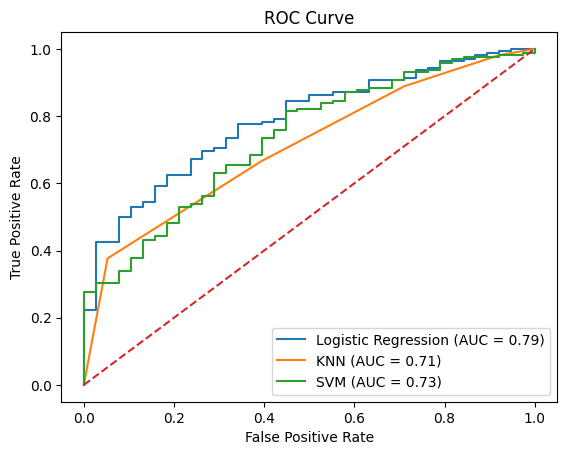

In [67]:
def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.figure()

plot_roc(lr, X_test, y_test, "Logistic Regression")
plot_roc(knn, X_test, y_test, "KNN")
plot_roc(svm, X_test, y_test, "SVM")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [68]:
def plot_confusion(model,X_test,y_test,title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("CONFUSION MATRIX")
    plt.show()

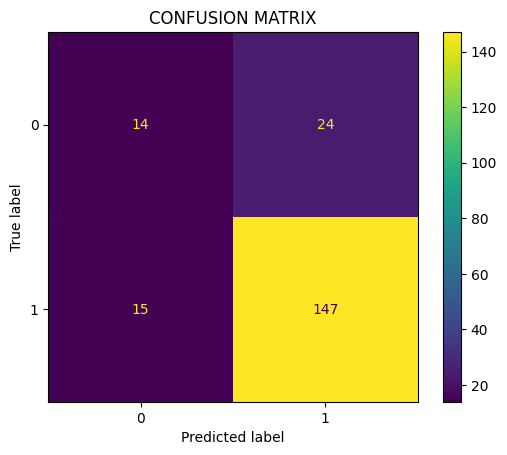

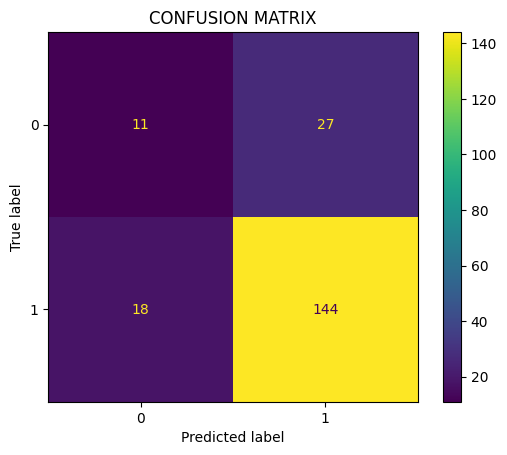

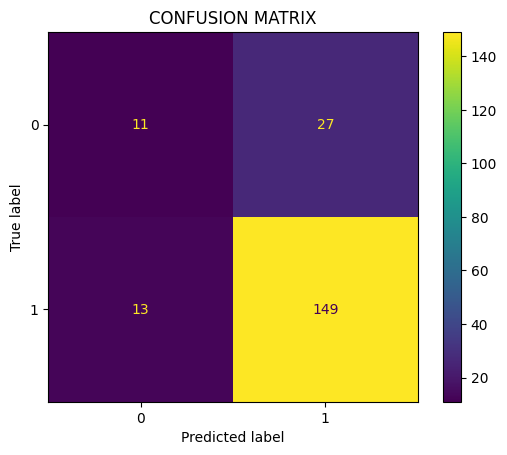

In [69]:
plot_confusion(lr, X_test, y_test, "Logistic Regression")
plot_confusion(knn, X_test, y_test, "KNN")
plot_confusion(svm, X_test, y_test, "SVM")

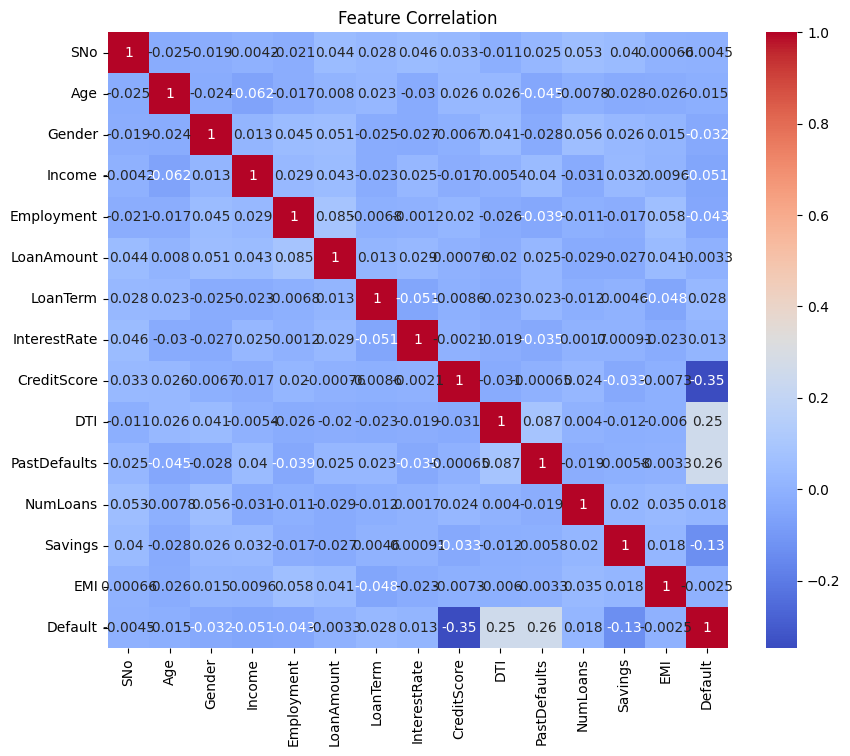

In [71]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()